In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Callable, Dict, List

def trapz_uniform(u: np.ndarray, dx: float) -> float:
    return dx * (0.5 * u[0] + u[1:-1].sum() + 0.5 * u[-1])

def k_variable(x: np.ndarray, k0: float) -> np.ndarray:
    return k0 * (1.0 + 0.5 * np.sin(2.0 * np.pi * x))

def k_constant(x: np.ndarray, k0: float) -> np.ndarray:
    return k0 * np.ones_like(x)

def L_operator(u: np.ndarray, k_vals: np.ndarray, dx: float) -> np.ndarray:
    k_plus  = 0.5 * (k_vals[2:] + k_vals[1:-1])
    k_minus = 0.5 * (k_vals[1:-1] + k_vals[:-2])
    du_plus  = u[2:]   - u[1:-1]
    du_minus = u[1:-1] - u[:-2]
    L_int = (k_plus * du_plus - k_minus * du_minus) / (dx * dx)
    out = np.zeros_like(u)
    out[1:-1] = L_int
    return out

def solve_ftcs(Nx:int, L:float, T:float, kfun:Callable[[np.ndarray,float],np.ndarray], k0:float, cfl:float=0.4, save_times=None) -> Dict[str,np.ndarray]:
    x = np.linspace(0.0, L, Nx + 1)
    dx = L / Nx
    k_vals = kfun(x, k0)
    dt = cfl * dx * dx / (2.0 * np.max(k_vals))
    Nt = int(np.ceil(T / dt))
    dt = T / Nt
    u = np.zeros_like(x); u[0]=1.0; u[-1]=u[-2]
    times = np.linspace(0.0, T, Nt+1)
    energies = np.empty(Nt+1); energies[0] = trapz_uniform(u, dx)
    saved = {}
    save_set = set(save_times or [])
    if 0.0 in save_set:
        saved[0.0] = u.copy()
    for n in range(1, Nt+1):
        k_plus  = 0.5 * (k_vals[2:] + k_vals[1:-1])
        k_minus = 0.5 * (k_vals[1:-1] + k_vals[:-2])
        du = (k_plus*(u[2:]-u[1:-1]) - k_minus*(u[1:-1]-u[:-2])) * (dt/(dx*dx))
        u[1:-1] += du
        u[0]=1.0; u[-1]=u[-2]
        energies[n] = trapz_uniform(u, dx)
        t_now = n * dt
        for ts in save_set:
            if ts not in saved and abs(t_now - ts) <= 0.5 * dt:
                saved[ts] = u.copy()
    return {"x":x,"u":u,"times":times,"energies":energies,"dt":dt,"dx":dx,"snapshots":saved}

def thomas_solve(a: np.ndarray, b: np.ndarray, c: np.ndarray, d: np.ndarray) -> np.ndarray:
    n = len(b)
    ac, bc, cc, dc = a.copy(), b.copy(), c.copy(), d.copy()
    for i in range(1, n):
        m = ac[i] / bc[i - 1]
        bc[i] = bc[i] - m * cc[i - 1]
        dc[i] = dc[i] - m * dc[i - 1]
    x = np.zeros(n)
    x[-1] = dc[-1] / bc[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]
    return x

def solve_crank_nicolson(Nx:int, L:float, T:float, kfun:Callable[[np.ndarray,float],np.ndarray], k0:float, dt:float, save_times=None) -> Dict[str,np.ndarray]:
    x = np.linspace(0.0, L, Nx + 1)
    dx = L / Nx
    k_vals = kfun(x, k0)
    k_plus  = 0.5 * (k_vals[2:] + k_vals[1:-1])
    k_minus = 0.5 * (k_vals[1:-1] + k_vals[:-2])
    sigma_plus  = (dt / (2.0 * dx * dx)) * k_plus
    sigma_minus = (dt / (2.0 * dx * dx)) * k_minus
    a = np.zeros(Nx+1); b = np.zeros(Nx+1); c = np.zeros(Nx+1)
    b[1:-1] = 1.0 + (sigma_plus + sigma_minus)
    a[2:]   = -sigma_minus
    c[1:-1] = -sigma_plus
    b[0]=1.0; a[0]=0.0; c[0]=0.0
    b[-1]=1.0; a[-1]=-1.0; c[-1]=0.0
    u = np.zeros_like(x); u[0]=1.0; u[-1]=u[-2]
    Nt = int(np.ceil(T/dt)); dt = T/Nt
    times = np.linspace(0.0, T, Nt+1)
    energies = np.empty(Nt+1); energies[0]=trapz_uniform(u,dx)
    saved = {}
    save_set = set(save_times or [])
    if 0.0 in save_set:
        saved[0.0] = u.copy()
    for n in range(1,Nt+1):
        Lu_int = (k_plus*(u[2:] - u[1:-1]) - k_minus*(u[1:-1] - u[:-2])) / (dx*dx)
        Lu = np.zeros_like(u); Lu[1:-1] = Lu_int
        rhs = u + 0.5*dt*Lu
        rhs[0]=1.0; rhs[-1]=0.0
        u = thomas_solve(a,b,c,rhs)
        energies[n] = trapz_uniform(u, dx)
        t_now = n * dt
        for ts in save_set:
            if ts not in saved and abs(t_now - ts) <= 0.5 * dt:
                saved[ts] = u.copy()
    return {"x":x,"u":u,"times":times,"energies":energies,"dt":dt,"dx":dx,"snapshots":saved}

def analytic_const_k_u(x: np.ndarray, t: float, k0: float, n_terms: int = 200) -> np.ndarray:
    if t == 0.0:
        return np.zeros_like(x)
    u = np.ones_like(x)
    for n in range(n_terms):
        alpha = (2*n+1)*np.pi/2.0
        u -= (2.0/alpha) * np.sin(alpha*x) * np.exp(-k0*alpha*alpha*t)
    return u

def analytic_const_k_energy(t: float, k0: float, n_terms: int = 200) -> float:
    if t == 0.0:
        return 0.0
    S = 0.0
    for n in range(n_terms):
        alpha = (2*n+1)*np.pi/2.0
        S += 2.0/(alpha*alpha) * np.exp(-k0*alpha*alpha*t)
    return 1.0 - S

def convergence_study(k0: float, L: float, T: float, cfl: float, N_list: List[int]) -> pd.DataFrame:
    rows = []
    for Nx in N_list:
        x = np.linspace(0.0, L, Nx + 1)
        dx = L / Nx
        res_ftcs = solve_ftcs(Nx, L, T, k_constant, k0, cfl=cfl, save_times=[])
        res_cn   = solve_crank_nicolson(Nx, L, T, k_constant, k0, dt=res_ftcs["dt"], save_times=[])
        u_exact = analytic_const_k_u(x, T, k0, n_terms=300)
        err_ftcs = np.sqrt(dx * np.sum((res_ftcs["u"] - u_exact)**2))
        err_cn   = np.sqrt(dx * np.sum((res_cn["u"]   - u_exact)**2))
        rows.append({"Nx":Nx,"dx":dx,"dt (FTCS)":res_ftcs["dt"],"dt (CN)":res_cn["dt"],
                     "L2 error FTCS":err_ftcs,"L2 error CN":err_cn})
    df = pd.DataFrame(rows).sort_values("dx", ascending=False).reset_index(drop=True)
    eoc_ftcs=[np.nan]; eoc_cn=[np.nan]
    for i in range(1,len(df)):
        h1,h2=df.loc[i-1,"dx"],df.loc[i,"dx"]
        e1f,e2f=df.loc[i-1,"L2 error FTCS"],df.loc[i,"L2 error FTCS"]
        e1c,e2c=df.loc[i-1,"L2 error CN"],df.loc[i,"L2 error CN"]
        eoc_ftcs.append(np.log(e1f/e2f)/np.log(h1/h2))
        eoc_cn.append(np.log(e1c/e2c)/np.log(h1/h2))
    df["EOC FTCS"]=eoc_ftcs; df["EOC CN"]=eoc_cn
    return df


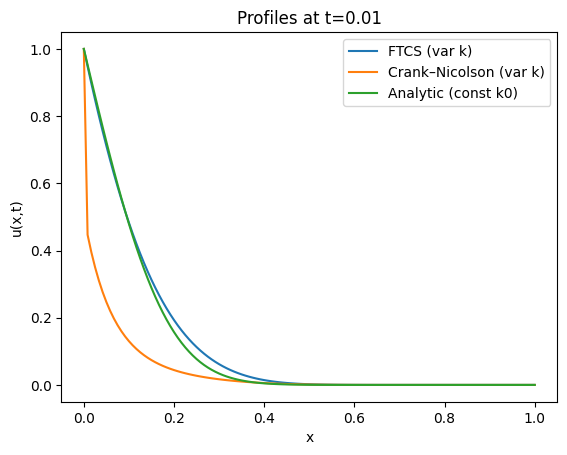

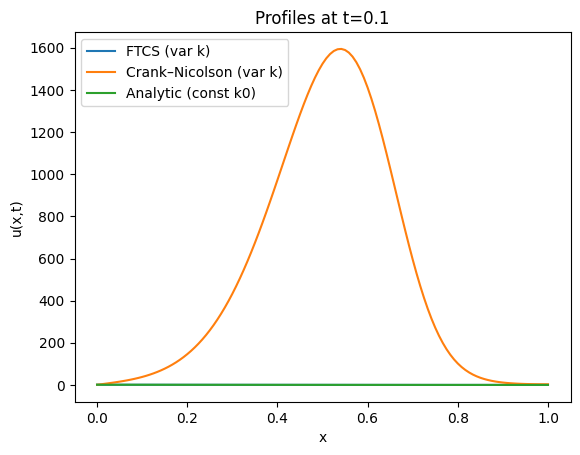

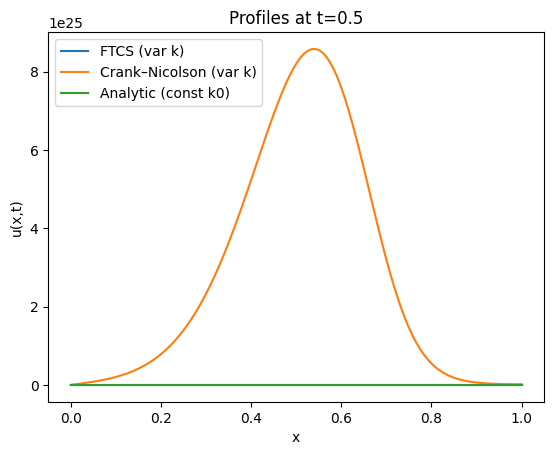

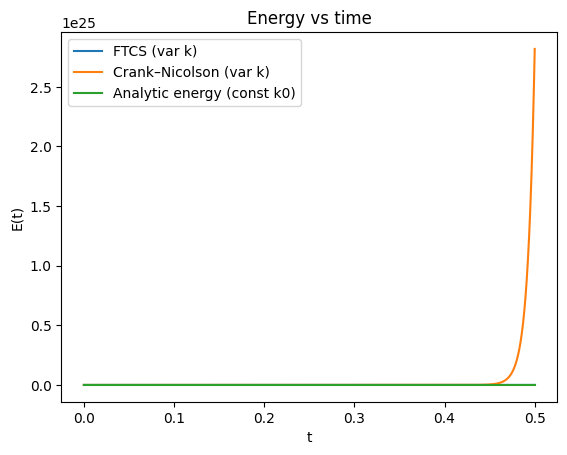

,Nx,dx,dt (FTCS),dt (CN),L2 error FTCS,L2 error CN,EOC FTCS,EOC CN
0,40,0.02500,0.000125,0.000125,0.000219,0.184101,NaN,NaN
1,80,0.01250,0.000031,0.000031,0.000070,0.188163,1.637865,-0.031480
2,160,0.00625,0.000008,0.000008,0.000028,0.190194,1.355623,-0.015492


In [2]:
L = 1.0
k0 = 1.0
Nx_plot = 120
cfl = 0.4
T_final = 0.5
t_snapshots = [0.01, 0.1, 0.5]

res_ftcs_var = solve_ftcs(Nx_plot, L, T_final, k_variable, k0, cfl=cfl, save_times=t_snapshots)
res_cn_var   = solve_crank_nicolson(Nx_plot, L, T_final, k_variable, k0, dt=res_ftcs_var['dt'], save_times=t_snapshots)

x_plot = res_ftcs_var['x']
snap_anal = {t: analytic_const_k_u(x_plot, t, k0, n_terms=300) for t in t_snapshots}

for t in t_snapshots:
    plt.figure()
    plt.plot(x_plot, res_ftcs_var['snapshots'][t], label='FTCS (var k)')
    plt.plot(x_plot, res_cn_var['snapshots'][t],   label='Crank–Nicolson (var k)')
    plt.plot(x_plot, snap_anal[t],                 label='Analytic (const k0)')
    plt.xlabel('x'); plt.ylabel('u(x,t)'); plt.title(f'Profiles at t={t}')
    plt.legend(); plt.show()

plt.figure()
plt.plot(res_ftcs_var['times'], res_ftcs_var['energies'], label='FTCS (var k)')
plt.plot(res_cn_var['times'],   res_cn_var['energies'],   label='Crank–Nicolson (var k)')
t_dense = np.linspace(0.0, T_final, 400)
E_an = np.array([analytic_const_k_energy(t, k0, n_terms=300) for t in t_dense])
plt.plot(t_dense, E_an, label='Analytic energy (const k0)')
plt.xlabel('t'); plt.ylabel('E(t)'); plt.title('Energy vs time')
plt.legend(); plt.show()

# Сходимость (const k)
df_conv = convergence_study(k0, L, T=0.05, cfl=cfl, N_list=[40,80,160])
df_conv
